In [1]:
# Cell 1: Install & Import Libraries
!pip install -q kagglehub torch torchvision torcheval scikit-learn matplotlib seaborn pillow

import os
import shutil
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 3.4 MB/s eta 0:00:00
Using compute device: cpu


In [2]:
# Cell 2: Download Dataset
import kagglehub

# Download latest version of Kermany et al. Chest X-Ray dataset
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded dataset path:", dataset_path)

# Verify base directory structure
base_dir = os.path.join(dataset_path, "chest_xray")
if not os.path.exists(base_dir):
    base_dir = dataset_path  # Fallback if unzipped at root

print("Base directory contents:", os.listdir(base_dir))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded dataset path: /kaggle/input/chest-xray-pneumonia
Base directory contents: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [3]:
# Cell 3: Dataset Splitting and Directory Structuring
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

def count_images(directory):
    counts = {}
    for cls in ['NORMAL', 'PNEUMONIA']:
        p = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(p)) if os.path.exists(p) else 0
    return counts

print("Original Train counts:", count_images(train_dir))
print("Original Val counts:  ", count_images(val_dir))
print("Original Test counts: ", count_images(test_dir))

Original Train counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Original Val counts:   {'NORMAL': 8, 'PNEUMONIA': 8}
Original Test counts:  {'NORMAL': 234, 'PNEUMONIA': 390}


/tmp/ipykernel_2083/1860306701.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette=["#3498db", "#e74c3c"])


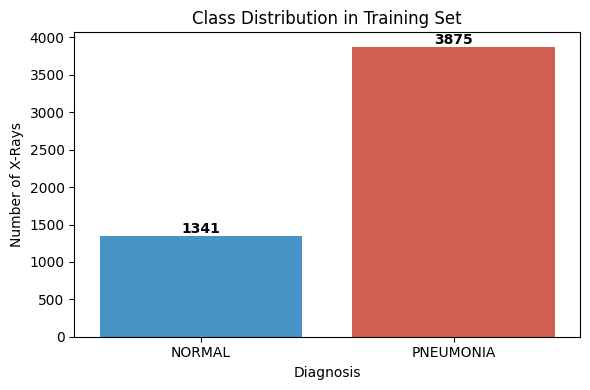

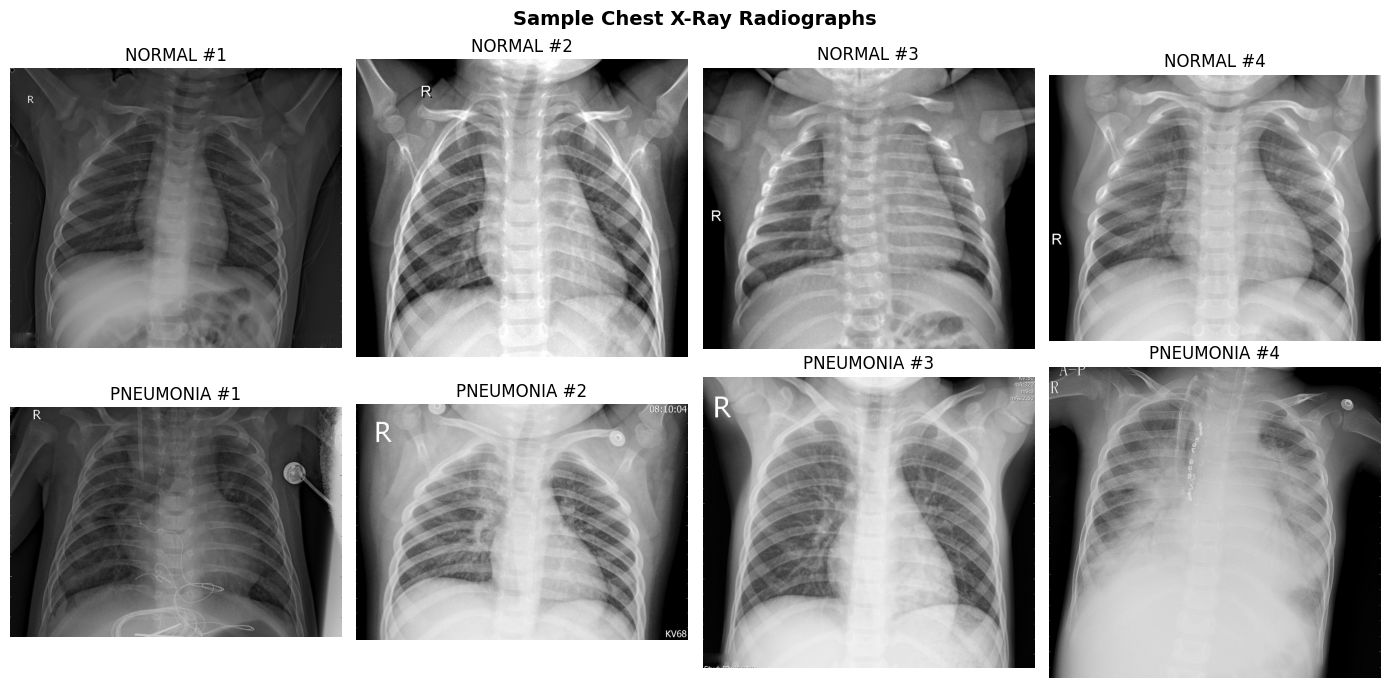

In [4]:
# Cell 4: Exploratory Data Analysis (Class Distribution & Sample Visualizations)
classes = ['NORMAL', 'PNEUMONIA']
train_counts = count_images(train_dir)

plt.figure(figsize=(6, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette=["#3498db", "#e74c3c"])
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of X-Rays")
plt.xlabel("Diagnosis")
for i, v in enumerate(train_counts.values()):
    plt.text(i, v + 40, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize Sample Images from both classes
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row_idx, cls in enumerate(classes):
    sample_imgs = glob.glob(os.path.join(train_dir, cls, "*.jpeg"))[:4]
    for col_idx, img_path in enumerate(sample_imgs):
        ax = axes[row_idx, col_idx]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"{cls} #{col_idx+1}")
        ax.axis('off')
plt.suptitle("Sample Chest X-Ray Radiographs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Cell 5: Transforms and DataLoaders
# ImageNet standardization
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]
IMG_SIZE  = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# Load full training + validation sets and create a solid 85/15 split
from torch.utils.data import ConcatDataset

raw_train_set = datasets.ImageFolder(train_dir)
raw_val_set = datasets.ImageFolder(val_dir)
full_training_pool = ConcatDataset([raw_train_set, raw_val_set])

# Extract targets for class weighting
train_targets = [sample[1] for sample in raw_train_set.samples] + [sample[1] for sample in raw_val_set.samples]
pneumonia_count = sum(train_targets)
normal_count = len(train_targets) - pneumonia_count

# Class weight calculation to handle class imbalance
pos_weight = torch.tensor([normal_count / pneumonia_count]).to(device)
print(f"Class imbalance ratio (Normal / Pneumonia): {pos_weight.item():.4f}")

total_len = len(full_training_pool)
val_len = int(0.15 * total_len)
train_len = total_len - val_len

train_subset, val_subset = random_split(
    full_training_pool,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply respective transforms using wrapper class
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Final Datasets & Loaders
train_dataset = TransformedDataset(train_subset, transform=train_transforms)
val_dataset   = TransformedDataset(val_subset, transform=eval_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Dataset summary: Train = {len(train_dataset)}, Val = {len(val_dataset)}, Test = {len(test_dataset)}")

Class imbalance ratio (Normal / Pneumonia): 0.3474
Dataset summary: Train = 4448, Val = 784, Test = 624


In [6]:
# Cell 6: Build CNN Model (ResNet-18 Backbone with Custom Classifier Head)
def build_pneumonia_cnn(pretrained=True):
    # Load ResNet-18
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)

    # Freeze initial feature extraction layers (optional, fine-tuning final block)
    for param in list(model.parameters())[:-12]:
        param.requires_grad = False

    # Replace final classification layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128, 1)  # Single logit output for binary classification
    )
    return model

model = build_pneumonia_cnn(pretrained=True).to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
# Cell 7: Training Loop with BCEWithLogitsLoss and Checkpointing
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 10
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss, correct_preds, total_preds = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_preds += (preds == labels).sum().item()
        total_preds += labels.size(0)

    epoch_train_loss = running_loss / total_preds
    epoch_train_acc = correct_preds / total_preds

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

    # Save best checkpoint
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_pneumonia_cnn.pth")
        print("  --> Best model weights saved!")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/10] Train Loss: 0.1161 | Train Acc: 91.37% | Val Loss: 0.0690 | Val Acc: 95.41%
  --> Best model weights saved!
Epoch [02/10] Train Loss: 0.0459 | Train Acc: 96.36% | Val Loss: 0.0500 | Val Acc: 96.30%
  --> Best model weights saved!
Epoch [03/10] Train Loss: 0.0427 | Train Acc: 96.70% | Val Loss: 0.0670 | Val Acc: 94.26%
Epoch [04/10] Train Loss: 0.0319 | Train Acc: 97.55% | Val Loss: 0.0463 | Val Acc: 97.70%
  --> Best model weights saved!
Epoch [05/10] Train Loss: 0.0265 | Train Acc: 98.09% | Val Loss: 0.0495 | Val Acc: 97.07%
Epoch [06/10] Train Loss: 0.0227 | Train Acc: 98.36% | Val Loss: 0.0427 | Val Acc: 97.07%
  --> Best model weights saved!
Epoch [07/10] Train Loss: 0.0222 | Train Acc: 98.27% | Val Loss: 0.0641 | Val Acc: 95.66%
Epoch [08/10] Train Loss: 0.0200 | Train Acc: 98.47% | Val Loss: 0.0526 | Val Acc: 96.94%
Epoch [09/10] Train Loss: 0.0205 | Train Acc: 98.31% | Val Loss: 0.0541 | Val Acc: 96.68%
Epoch [10/10] Train Loss: 0.0174 | Train Acc: 98.85% | Val Los

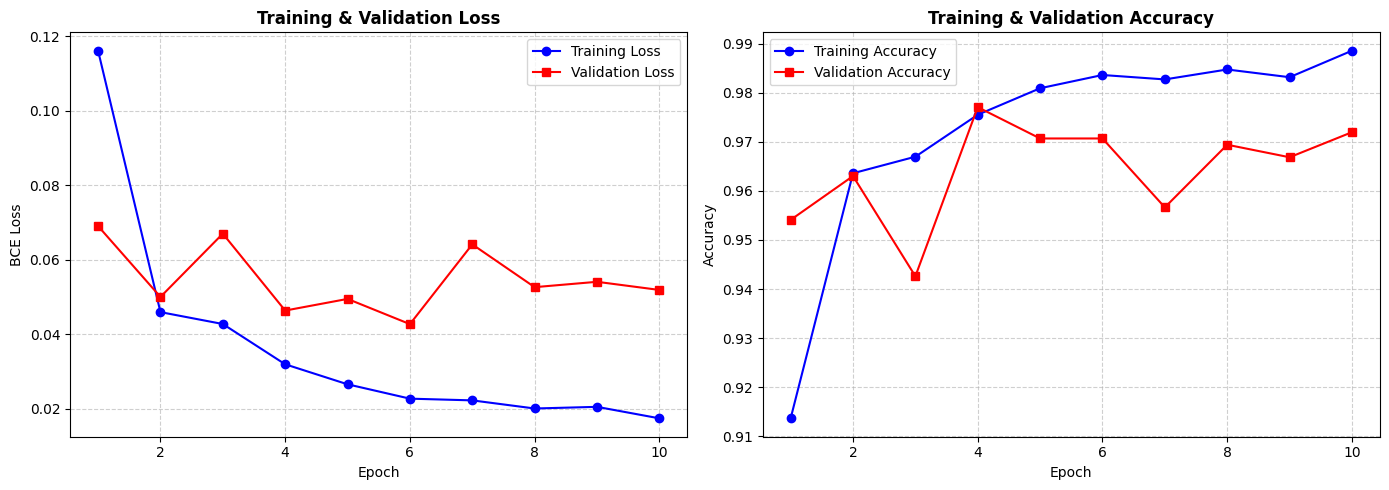

In [8]:
# Cell 8: Plot Loss and Accuracy Curves
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss')
plt.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy')
plt.plot(epochs_range, history['val_acc'], 'r-s', label='Validation Accuracy')
plt.title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

In [9]:
# Cell 9: Rigorous Test Set Evaluation
# Load best weights
model.load_state_dict(torch.load("best_pneumonia_cnn.pth"))
model.eval()

y_true = []
y_probs = []
y_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)

        y_probs.extend(probs)
        y_preds.extend(preds)
        y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_preds = np.array(y_preds)

# Classification Report
target_names = ['NORMAL (0)', 'PNEUMONIA (1)']
print("\n=== CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_true, y_preds, target_names=target_names, digits=4))

# Compute ROC-AUC
auc_score = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")


=== CLASSIFICATION REPORT (TEST SET) ===
               precision    recall  f1-score   support

   NORMAL (0)     0.9744    0.6496    0.7795       234
PNEUMONIA (1)     0.8248    0.9897    0.8998       390

     accuracy                         0.8622       624
    macro avg     0.8996    0.8197    0.8396       624
 weighted avg     0.8809    0.8622    0.8547       624

ROC-AUC Score: 0.9577


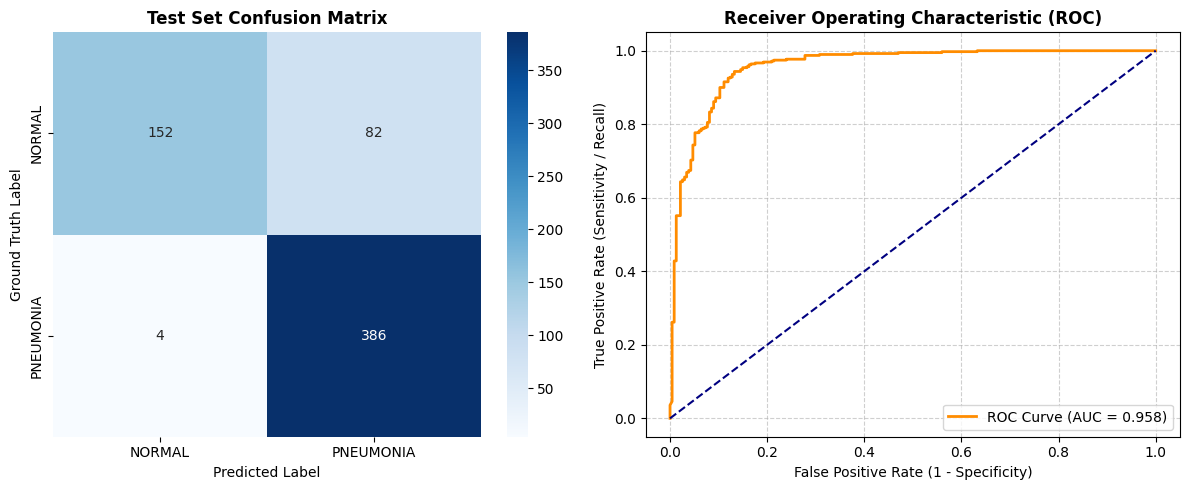

In [10]:
# Cell 10: Confusion Matrix & ROC Curve Plots
cm = confusion_matrix(y_true, y_preds)

plt.figure(figsize=(12, 5))

# Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Test Set Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=300)
plt.show()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


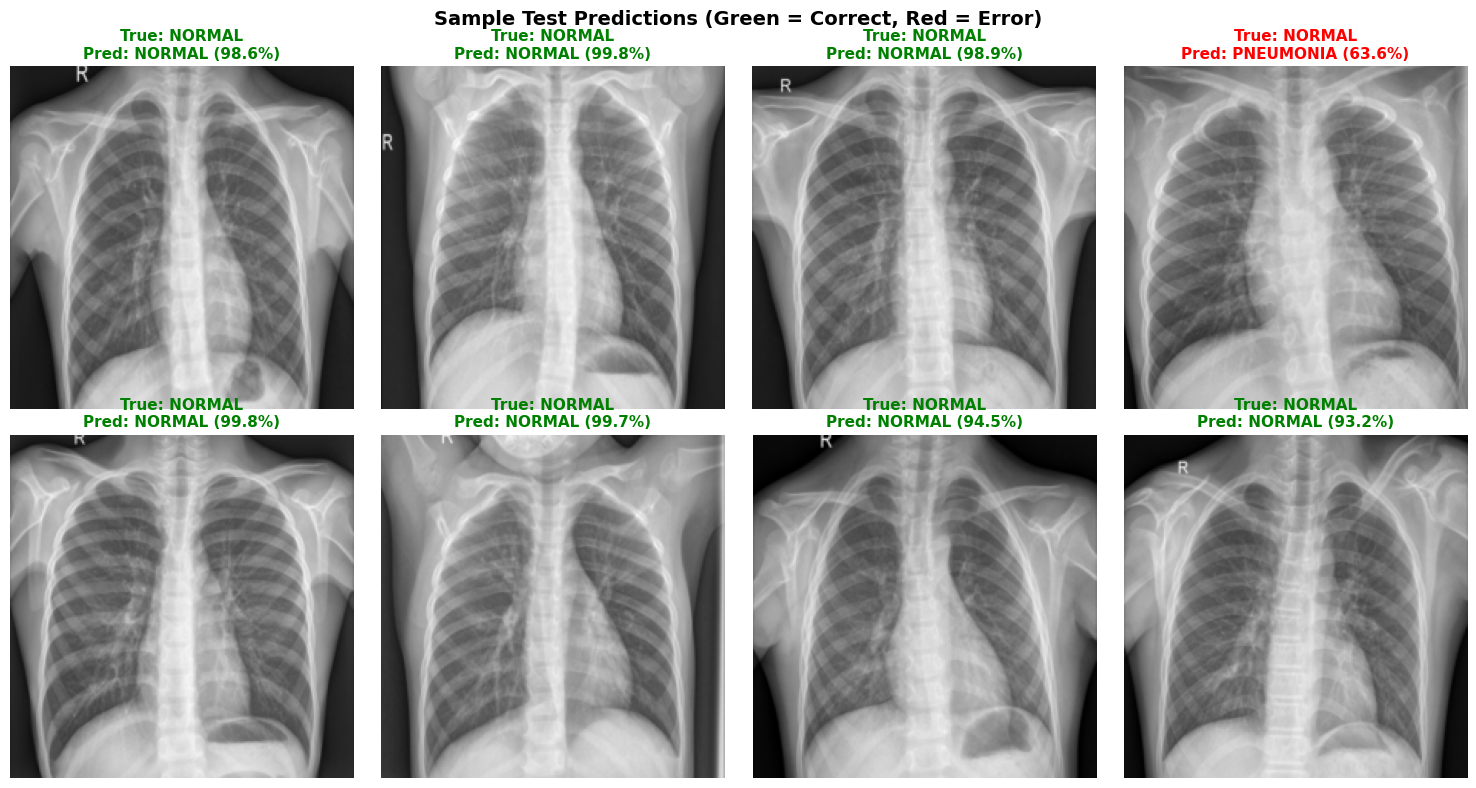

In [11]:
# Cell 11: Visualizing Predictions vs Ground Truth
def denormalize(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(NORM_MEAN, NORM_STD)],
        std=[1/s for s in NORM_STD]
    )
    return inv_normalize(tensor).clamp(0, 1)

# Grab a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    probs = torch.sigmoid(outputs).cpu().numpy().flatten()
    preds = (probs >= 0.5).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    img = denormalize(images[i]).permute(1, 2, 0).cpu().numpy()

    true_cls = classes[labels[i].item()]
    pred_cls = classes[preds[i]]
    confidence = probs[i] if preds[i] == 1 else (1 - probs[i])

    is_correct = (labels[i].item() == preds[i])
    title_color = "green" if is_correct else "red"

    ax.imshow(img)
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({confidence*100:.1f}%)",
                 color=title_color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Test Predictions (Green = Correct, Red = Error)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=300)
plt.show()